In [ ]:
!pip install imgaug
!

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/948.0 kB ? eta -:--:--
   ---------------------------------------- 948.0/948.0 kB 45.7 MB/s  0:00:00
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ----------- ---------------------------- 11.5/39.5 MB 60.0 MB/s eta 0:00:01
   ------------------------ --------------- 23.9/39.5 MB 58.1 MB/s eta 0:00:01
   ---------------------------------------  39.3/39.5 MB 65.8 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 61.2 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 91.3 MB/s  0:00:00

   ---------------------------------------- 0/3 [Shapely]
   ---------------------------------------- 0/3 [Shapely]
   ------------- -------------------------- 1/3 [opencv-py

이 에러는 이미지 처리 라이브러리(torchvision, PIL)와 시각화 라이브러리(matplotlib)가 내부적으로 계산을 가속화할 때 사용하는 OpenMP(중복 연산 라이브러리)가 서로 충돌하면서 커널(코드 실행 프로세스)이 강제로 종료(die)되어 발생하는 현상입니다.

plt.imshow()를 실행하려는 순간, 두 라이브러리가 동시에 동일한 연산 파일을 실행하려고 하니 컴퓨터가 위험하다고 판단해 아예 주피터 노트북 커널을 꺼버린 것입니다.

이 문제를 해결하는 가장 확실하고 간단한 방법 2가지를 알려드릴게요.

In [1]:
!conda install -c intel mkl

Retrieving notices: done
Channels:
 - intel
 - defaults
Platform: win-64



UnavailableInvalidChannel: HTTP 403 FORBIDDEN for channel intel <https://conda.anaconda.org/intel>

The channel is not accessible or is invalid.

You will need to adjust your conda configuration to proceed.
Use `conda config --show channels` to view your configuration's current state,
and use `conda config --show-sources` to view config file locations.




이미지 데이터
이미지 데이터 증강은 객체 검출 및 인식, 이미지 분류와 같은 이미지 처리 모델을 구성할 때 데이터세트
의 크기를 쉽게 늘리기 위해 사용된다. 이미지 데이터 증강 방법은 크게 회전, 대칭, 이동, 크기 조정 등
이 있다.
이 책에서는 토치비전(torchvision) 라이브러리와 이미지 증강(imgaug) 라이브러리23를 활용해 이미
지 데이터를 증강한다.
토치비전 라이브러리는 이미지 데이터를 증강하고 변형하기 위한 기본적인 메서드를 제공한다. 이미지
증강 라이브러리는 토치비전 라이브러리에서 제공하지 않는 증강 방법을 제공한다.
이미지 증강 라이브러리는 다음과 같이 설치할 수 있다.

In [1]:
from matplotlib import pyplot as plt

변환 적용 방법
이미지 데이터 증강 방법은 토치비전 라이브러리의 변환(transforms) 모듈을 통해 수행할 수 있다.
변환 모듈에 이미지 변환에 관련된 기능이 포함돼 있으며, 여러 모델 매개변수를 묶어주는 시퀀셜
(Sequential)과 같은 역할을 하는 통합(Compose) 클래스를 함께 사용해 증강을 적용한다. 다음 예제
4.16은 통합 클래스 사용 방법을 보여준다.


torch.Size([3, 512, 512])


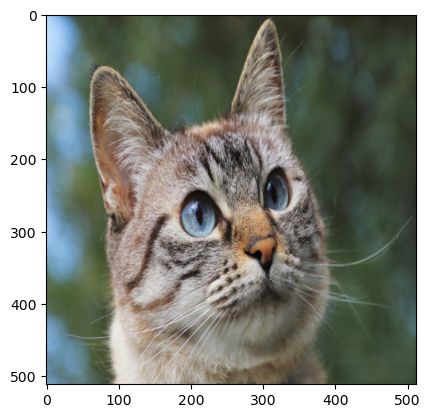

In [1]:
from PIL import Image
from torchvision import transforms
from matplotlib import pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 이 줄을 최상단에 추가!


transform = transforms.Compose(
    [
        transforms.Resize(size=(512, 512)),
        transforms.ToTensor()
    ]
)

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
print(transformed_image.shape)
# plt.imshow(transformed_image)
plt.imshow(transformed_image.permute(1, 2, 0).numpy())

예제 4.16은 이미지 데이터를 512X512 크기로 변환하고 파이토치에서 사용하는 텐서 타입으로 변환
하는 과정을 수행했다. 이미지 증강은 어떠한 순서로 진행하는가에 따라 픽셀 데이터의 변환 폭과 결과
물이 크게 달라질 수 있다.
예를 들어 이미지를 잘라낸 다음 512x512 크기로 변환했을 때와 512乂512 크기로 변환한 다음 잘
라냈을 때 두 결과물은 크게 달라진다. 또한 여러 번에 나눠 이미지 증강을 적용하면 코드가 복잡해진
다. 이러한 문제를 방지하고자 통합 클래스를 사용해 증강 방법을 정렬하고 하나로 묶어 데이터 핸들링
(Data Handling)을 수행할 수 있다.
텐서화 클래스(transforms.ToTensor)는 PIL.Image 형식을 Tensor 형식으로 변환한다. 텐서화 클래스
는 [0~255] 범위의 픽셀값을 [0.0~1.0] 사이의 값으로 최대 최소 정규화(Min-max Normalization)
를 수행한다. 또한 입력 데이터의 [높이, 너비. 채널] 형태를 [채널, 높이. 너비] 형태로 변환한다.
대부분의 이미지 증강 클래스는 PIL.Image 형식을 대상으로 변환한다. 파이토치에서는 Tensor 형식을
사용하므로 PIL. Image 형식을 증강 자체에서 변환해 활용한다.24
24 PIL.Image 형식이라면 transformed_image.show()를통해 이미자를확인할수 있다.
만약 데이터세트에 일괄 적용한다면 torchvision.datasets.ImageFolder와 같은 이미지 데이터세트
클래스의 transform 매개변수에 입력해 활용할 수 있다

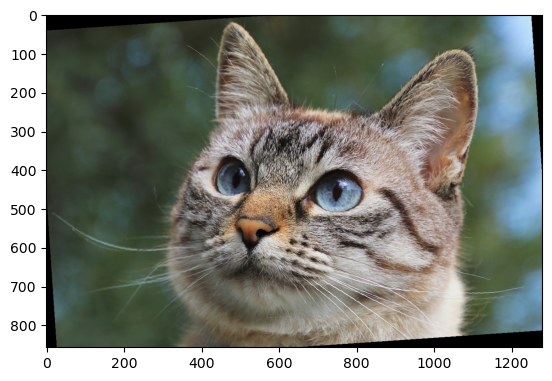

In [2]:
from PIL import Image
from torchvision import transforms
from matplotlib import pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 이 줄을 최상단에 추가!


transform = transforms.Compose(
    [
        transforms.RandomRotation(degrees=30, expand=False, center=None),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5)
    ]
)

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

자르기 및 패딩
객체 인식과 같은 모델을 구성한다고 가정했을 때 학습 데이터의 크기가 일정하지 않거나 주요한 객체가
일부 영역에만 작게 존재할 수도 있다. 이러한 경우 객체가 존재하는 위치로 이미지를 잘라 불필요한 특
징을 감소시키거나 패딩을 주어 이미지 크기를 동일한 크기로 맞출 수 있다.
하지만 이미지를 과도하게 잘라 검출하려는 객체가 포함되지 않거나 너무 많은 패딩을 주어 특징의 영향
이 감소할 수도 있으므로 주의해 사용해야 한다.
다음 예제 4.18은 토치 비전 라이브러리를 사용해 자르기 및 패딩 적용 방법을 보여준다.


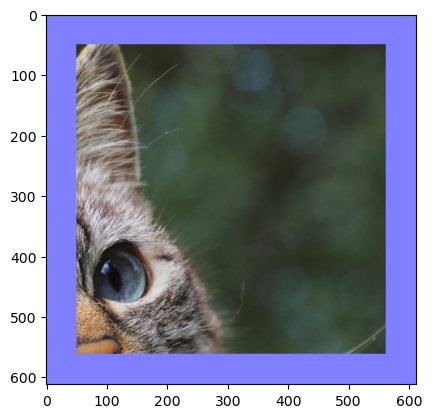

In [3]:
from PIL import Image
from torchvision import transforms
from matplotlib import pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 이 줄을 최상단에 추가!

transform = transforms.Compose(
    [
        transforms.RandomCrop(size=(512, 512)),
        transforms.Pad(padding=50, fill=(127, 127, 255), padding_mode="constant")
    ]
)

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

크기 조정
수집된 이미지 데이터는 모두 동일한 크기의 이미지로 수집되거나 편집하기가 어렵다. 이미지 처리 모델
학습을 원활하게 진행하기 위해서는 학습 데이터에 사용되는 이미지의 크기가 모두 일정해야 한다. 하
지만 데이터 자체를 수정하면 향후 모델이 입력받는 이미지 크기가 달라졌을 때 데이터 관리에 어려움이
생긴다. 이러한 문제를 방지하기 위해 증강 클래스에서 이미지 크기를 변환한다.
다음 예제 4.19는 토치비전 라이브러리를 사용해 크기를 조정하는 방법을 보여준다.


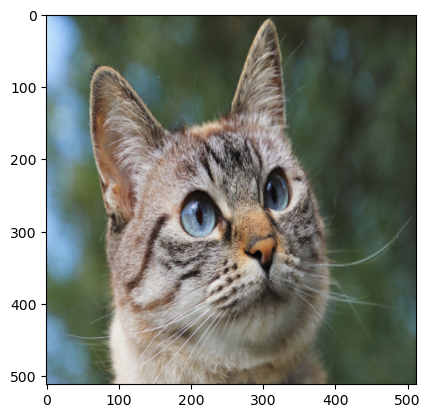

In [4]:
from PIL import Image
from torchvision import transforms
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 이 줄을 최상단에 추가!


transform = transforms.Compose(
    [
        transforms.Resize(size=(512, 512))
    ]
)

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

크기 조정(Resize) 클래스도 크기(size) 매개변수를 정수 또는 시퀀스로 입력받는다. 정수로 크기를 입
력받는 경우 높이나 너비 중 크기가 더 작은 값에 비율을 맞춰 크기가 수정된다. 예를 들어 원본 이미지
크기가 (500, 400)일 때. transforms.Resize(size=300)으로 변환하면 (300乂500三400, 300)=(375,
300)으로 크기가 수정된다.
크기 조정 클래스의 경우 특별한 경우가 아니라면 시퀀스 형태로 입력해 명시적으로 크기를 설정한다.
보편적으로 크기 조정 클래스는 정사각형으로 데이터를 정규화한다.


변형
이미지를 변형하는 경우 기하학적 변환(Geometric Transform)을 통해 이미지를 변경한다. 기하
학적 변환이란 인위적으로 확대, 축소, 위치 변경, 회전, 왜곡하는 등 이미지의 형태를 변환하는 것
을 의미한다. 기하학적 변환은 크게 아핀 변환(Affine Transformation)과 원근 변환(Perspective
Transformation) 이 있다.
아핀 변환은 2X3 행렬을 사용하며 행렬 곱셈에 벡터 합을 활용해 표현할 수 있는 변환을 의미하며, 원
근 변환은3x3 행렬을 사용하며, 호모그래피(Homography)로 모델링할수 있는 변환을 의미한다.
다음 예제 4.20은 토치비전 라이브러리를 사용해 아핀 변환을 적용하는 방법을 보여준다.

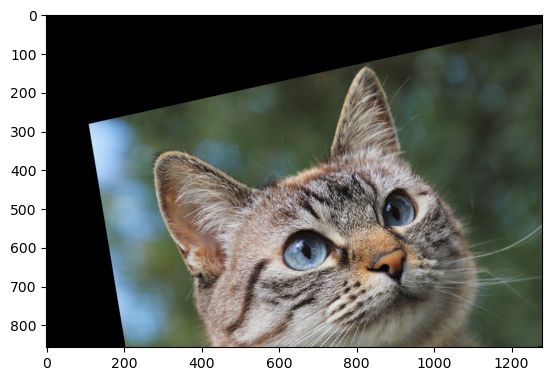

In [5]:
from PIL import Image
from torchvision import transforms


transform = transforms.Compose(
    [
        transforms.RandomAffine(
            degrees=15, translate=(0.2, 0.2),
            scale=(0.8, 1.2), shear=15
        )
    ]
)

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

아핀 변환은 각도(degrees), 이동(translate), 척도(scale), 전단(shear)을 입력해 이미지를 변형한다.
회전이나 이동 이외에도 중심점(원점)에서 임의로 설정된 점을 향하는 벡터를 선형 변환하므로 출력 결
과와 같이 이미지가 눕혀지거나 비틀어진 결과물을 얻을 수 있다.
이미지의 축을 비트는 것처럼 변환되므로 특징들을 유지하지만, 이미지 픽셀들이 큰 폭으로 변환되므로
가장 많은 변형이 일어난다

색상 변환
이미지 데이터의 특징은 픽셀값의 분포나 패턴에 크게 좌우된다. 앞선 변형들은 이러한 분포나 패턴을
비틀어 보간해 데이터를 증강한다고 볼 수 있다. 하지만 색상의 채도(Saturation), 명도(Brightness),

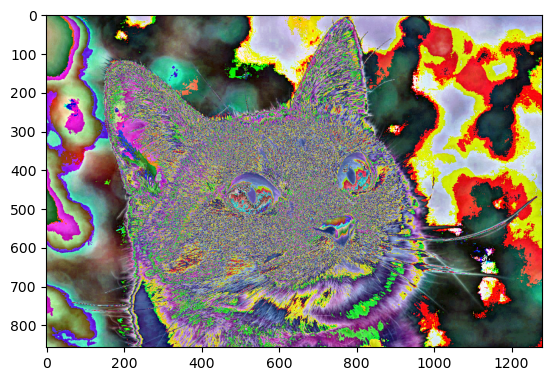

In [6]:
from PIL import Image
from torchvision import transforms


transform = transforms.Compose(
    [
        transforms.ColorJitter(
            brightness=0.3, contrast=0.3,
            saturation=0.3, hue=0.3
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225]
        ),
        transforms.ToPILImage()
    ]
)

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

대비(Contrast) 등은 크게 변경되지 않는다. 주로 색상의 위치나 패턴이 변경될 뿐 주 색상 값은 유지
된다.
모델이 이미지를 분석할 때 특정 색상에 편향되지 않도록 픽셀값을 변환하거나 정규화하면 모델을 더 일
반화해 분석 성능을 향상시키고 학습 시간을 단축시킬 수 있다.
다음 예제 4.21은 토치비전 라이브러리를 사용해 색상 변환 및 정규화를 적용하는 방식을 보여준다

색상 변환 클래스(ColorJitter)는 이미지의 밝기(brightness), 대비(contrast), 채도(saturation), 색
상(hue)을 변환한다. 이미지는 거리나 조명 등에 의해 색상(Color)이 크게 달라질 수 있다.
색상 변환 클래스를 통해 여러 색상으로 변형해 간접적으로 데이터세트의 일반화 효과를 얻을 수 있다.
또한 객체 검출이나 인식 과정에서 색상이 중요하지 않고 형태(Shape)가 더 중요한 경우 형태를 유지하
면서 색상 톤을 낮출 수 있다.
정규화 클래스(Normalize)는 픽셀의 평균과 표준편차를 활용해 정규화한다. 색상 변환 클래스처럼 픽셀
의 특징을 유지한 채 변환하는 것이 아닌 데이터를 정규화해 모델 성능을 높이는 데 중점을 둔다.
정규화 클래스는 PIL.Image 형식이 아닌 Tensor 형식을 입력으로 받는다. 정규화 방식은 (input
[channel] - mean[channel]) / std[channel]로 진행된다. 예제에서는 이미지로 출력값을 확인하기
위해 텐서 변환 클래스를 적용했다. 본래의 픽셀값을 확인하고자 한다면 수식을 반대로 적용하는 역정규
화(Denormalization)를 수행한다.

노이즈
이미지 처리 모델은 주로 합성곱 연산을 통해 학습을 진행한다. 예를 들어 이미지 내 3x3픽셀 영역을
합성곱 연산하면 1x1 크기의 특징이 계산될 수 있다. 즉, 픽셀값에 따라 특징을 추출하는 매개변수가
크게 달라질 수 있다.
노이즈 추가도 특정 픽셀값에 편향되지 않도록 임의의 노이즈를 추가해 모델의 일반화 능력을 높이는 데
사용된다. 또한 학습에 직접 포함되지 않더라도 테스트 데이터에 노이즈를 추가해 일반화 능력이나 강건
성(Robustness)을 평가하는 데 사용된다.
다음 예제 4.22는 이미지 증강 라이브러리를 사용해 노이즈를 추가하는 방법을 보여준다

(857, 1280, 3) uint8


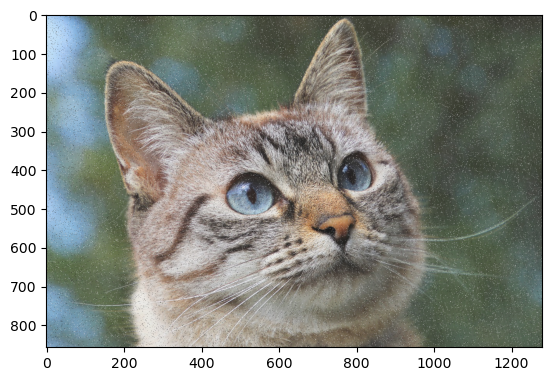

In [7]:
import numpy as np
np.bool = np.bool_ # Deprecated 오류 방지
from PIL import Image
from torchvision import transforms
from imgaug import augmenters as iaa


class IaaTransforms:
    def __init__(self):
        self.seq = iaa.Sequential([
            iaa.SaltAndPepper(p=(0.03, 0.07)),
            iaa.Rain(speed=(0.3, 0.7))
        ])
    
    def __call__(self, images): 
        images = np.array(images)
        print(images.shape, images.dtype)
        augmented = self.seq.augment_image(images)
        return Image.fromarray(augmented)


transform = transforms.Compose([
    IaaTransforms()
])

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

예제 4.22는 이미지 증강 라이브러리에서 지원하는 점잡음(Salt and pepper noise)과 빗방울 레
이어를 적용한 것이다. 이미지 증강 라이브러리의 증강 클래스는 넘파이의 ndarray 클래스를 입력
값과 출력값으로 사용한다. 토치비전은 PIL.Image 형식이나 Tensor 형식으로 증강을 적용하므로
laaTransforms 클래스를 선언해 적용한다.
laaTransforms 클래스의 초기화 메서드(__init__)에서 증강 방법을 설정한다. imgaug.augmenters 모
듈에서 이미지 증강 클래스를 사용할 수 있다.

컷아웃 및 무작위 자우기
컷아웃(Cutout)25과 무작위 지우기(Random Erasing)26는 거의 동일한 시점에 제안된 증강 및 정칙
화 방법이다. 컷아웃은 이미지에서 임의의 사각형 영역을 삭제하고 0의 픽셀값으로 채우는 방법이며, 무
작위 지우기는 임의의 사각형 영역을 삭제하고 무작위 픽셀값으로 채우는 방법이다.
25 https://arxiv.org/abs/17O8.O4896
26 https://arxiv.org/abs/1708.04552
27 특정 프레임에는 존재하지만 다른 프레임에는 존재하지 않는 영역
컷아웃은 동영상에서 폐색 영역(Occlusion)27에 대해 모델이 더 강건하게 해주며, 무작위 지우기는 일
부 영역이 누락되거나 잘렸을 때 더 강건한 모델을 만들 수 있게 한다. 두 가지 방법 모두 이미지의 객체
가 일부 누락되더라도 모델을 견고하게 만드는 증강 방법이다.
다음 예제 4.23은 토치비전 라이브러리를 사용해 무작위 지우기 방법을 보여준다.


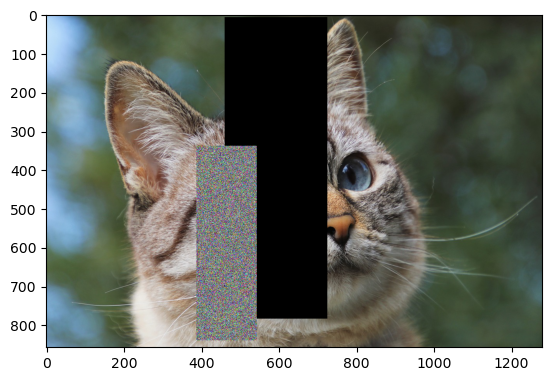

In [8]:
from PIL import Image
from torchvision import transforms


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomErasing(p=1.0, value=0),
    transforms.RandomErasing(p=1.0, value='random'),
    transforms.ToPILImage()
])

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

컷아웃과 무작위 지우기 방법 둘 다 무작위 지우기 클래스(RandomErasing)를 통해 적용할 수 있다. 무작
위 지우기 클래스의 값(value)을 0으로 할당하면 컷아웃 방법이 되며. random으로 입력하면 무작위 지
우기 방법이 된다.
단, 무작위 지우기 클래스는 Tensor 형식만 지원되므로 해당 클래스를 호출하기 전에 텐서 변환 클래스
를 호출해 Tensor 형식으로 변환해야 한다. 마지막으로 PIL 변환으로 시각화하여 출력 결과를 확인할 수
있다.


혼합 및 컷믹스
혼합(Mixup)28은 두 개 이상의 이미지를 혼합(Blending)해 새로운 이미지를 생성하는 방법이다. 픽셀
값을 선형으로 결합해 새 이미지를 생성한다.
28 https://arxiv.org/abs/1710.09412
29 하나의 객체가 두 개 이상의 클래스에 포함돠는 것
생성된 이미지는 두 개의 이미지가 겹쳐 흐릿한 형상을 지니게 된다. 혼합 방식으로 이미지 데이터를 증
강해 학습하면 레이블링이 다르게 태깅돼 있어도 더 낮은 오류를 보이며, 이미지를 혼합했기 때문에 다
중 레이블(Multi-label)29 문제에 대해서도 더 견고한 모델을 구성할 수 있다

컷믹스(CutMix)30는 네이버 클로바에서 발표한 이미지 증강 방법으로 이미지 패치(patch) 영역에 다른
이미지를 덮어씌우는 방법이다. 이미지 영역을 잘라내고 붙여넣기(Cut and paste) 하는 방법으로 볼
수 있다.
30 https://arxiv.org/abs/1905.04899
컷믹스는 패치 위에 새로운 패치를 덮어씌워 비교적 자연스러운 이미지를 구성한다. 모델이 이미지의 특
정 영역을 기억해 인식하는 문제를 완화하며, 이미지 전체를 보고 판단할 수 있게 일반화한다. 혼합과 컷
믹스를 시각화하면 그림 4.7과 같다.

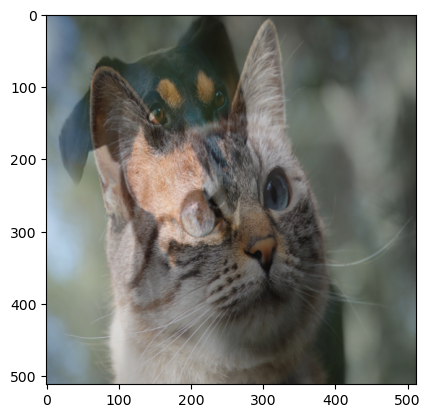

: 

In [ ]:
import numpy as np
from PIL import Image
from torchvision import transforms


class Mixup:
    def __init__(self, target, scale, alpha=0.5, beta=0.5):
        self.target = target
        self.scale = scale
        self.alpha = alpha
        self.beta = beta

    def __call__(self, image):
        image = np.array(image)
        target = self.target.resize(self.scale)
        target = np.array(target)
        mix_image = image * self.alpha + target * self.beta
        return Image.fromarray(mix_image.astype(np.uint8))


transform = transforms.Compose(
    [
        transforms.Resize((512, 512)),
        Mixup(
            target=Image.open("../datasets/images/dog.jpg"),
            scale=(512, 512),
            alpha=0.5,
            beta=0.5
        )
    ]
)

image = Image.open("../datasets/images/cat.jpg")
transformed_image = transform(image)
plt.imshow(transformed_image)

Mixup 클래스도 앞선 laaTransforms 클래스와 같은 방법으로 구현해 증강을 적용할 수 있다. target은
혼합하려는 이미지를 입력하고 scale을 통해 이미지 크기를 조절한다. alpha와 beta는 각 이미지의 혼
합 비율을 설정한다. 호출 메서드에서 간단한 넘파이 연산으로 두 이미지를 혼합할 수 있다.
텍스트 및 이미지 증강 방법은 모든 데이터에 적용하는 것이 아닌, 일부 데이터에만 적용해 증강한다. 만
약 이미지 혼합과 같이 모든 이미지에 두 이미지를 섞는다면 오히려 일반화 성능이 떨어지고 실제 데이
터와 거리가 먼 데이터 구조를 갖게 되어 부적절한 모델이 구성된다.
또한 색상 변환이나 정규화 같이 픽셀 데이터의 형태를 완전히 바꾸는 경우 모델 추론 과정에서도 동일
한 증강 방법이나 정규화 방법을 적용해야 모델이 데이터를 분석해 값을 인식할 수 있다.
데이터 증강은 모델 학습에 있어서 보편적으로 사용되는 방법이며. 부족한 데이터를 확보하고 모델의 일
반화 성능을 최대로 끌어올릴 수 있다.
다음 표 4.5는 토치비전 변환 모듈의 주요한 증강 방법을 정리한 것이다.

![nn](image/image%20copy%207.png)
![nn](image/image%20copy%208.png)
![nn](image/image%20copy%209.png)
![nn](image/image%20copy%210.png)